# Steam Reviews — Social Media & Network Analysis
**Course:** COSC2671 Social Media and Network Analytics  
**Research Question:** How does the sentiment of Steam reviews vary between genres, and do users review games only within a single genre or across multiple genres?

**Genres:** Horror | RPG | Strategy  
**Sections:**
1. Data Loading 
2. Text Preprocessing 
3. Sentiment Analysis 
4. Topic Modelling 
5. Network Analysis & Graphs 
6. Community Detection

---
## 0 – Imports

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import os, json, re, warnings
from itertools import combinations
from collections import Counter
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.parsing.preprocessing import STOPWORDS as GENSIM_STOPWORDS

import scipy.linalg
if not hasattr(scipy.linalg, 'triu'):
    scipy.linalg.triu = np.triu

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from wordcloud import WordCloud

# ── Network ───────────────────────────────────────────────────────────────────
import networkx as nx
from networkx.algorithms import bipartite
from networkx.algorithms.community import greedy_modularity_communities

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

STOP_WORDS = set(stopwords.words('english')).union(GENSIM_STOPWORDS)

# Shared colour palettes — used in every section
GENRE_PALETTE = {'Horror': '#c0392b', 'RPG': '#2980b9', 'Strategy': '#27ae60'}
SENT_COLORS   = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
SENT_ORDER    = ['Positive', 'Neutral', 'Negative']

print('All imports OK')

All imports OK


---
## 1 – Data Loading
*Source: LoadSteamReviews.ipynb*

Reviews collected via the Steam API using `steamreviews`, stored as one JSON per game in `data/`.

In [2]:
'''
Basic setup to download Steam reviews.
'''
# import steamreviews
# request_params = {
#     'filter': 'recent', 'language': 'english',
#     'purchase_type': 'steam', 'filter_offtopic_activity': 0, 'day_range': '365'
# }
# steamreviews.download_reviews_for_app_id_batch(chosen_request_params=request_params)

'\nBasic setup to download Steam reviews.\n'

In [3]:
appid_dict = {
    '1622910' : ['Still wakes the deep',                        'Horror'],
    '1196590' : ['Resident Evil Village',                       'Horror'],
    '3180070' : ['No Im not a Human',                           'Horror'],
    '541570'  : ['Sally Face - Episode one',                    'Horror'],
    '1929610' : ['Demonologist',                                'Horror'],
    '108710'  : ['Alan_Wake',                                   'Horror'],
    '238320'  : ['Outlast',                                     'Horror'],
    '506610'  : ["Five Nights at Freddy's: Sister location",    'Horror'],
    '214490'  : ['Alien: Isolation',                            'Horror'],
    '594330'  : ['Visage',                                      'Horror'],
    '2344520' : ['Diablo 4',                                    'RPG'],
    '489830'  : ['The Elder Scrolls V: Skyrim Special Edition', 'RPG'],
    '1245620' : ['ELDEN RING',                                  'RPG'],
    '306130'  : ['The Elder Scrolls Online',                    'RPG'],
    '1151340' : ['Fallout 76',                                  'RPG'],
    '39210'   : ['FINAL FANTASY XIV Online',                    'RPG'],
    '632470'  : ['Disco Elysium The Final Cut',                 'RPG'],
    '1091500' : ['Cyberpunk 2077',                              'RPG'],
    '1328670' : ['Mass Effect Legendary Edition',               'RPG'],
    '1716740' : ['Starfield',                                   'RPG'],
    '289070'  : ["Sid Meier's Civilization VI",                 'Strategy'],
    '1142710' : ['Total War: WARHAMMER III',                    'Strategy'],
    '281990'  : ['Stellaris',                                   'Strategy'],
    '1466860' : ['Age of Empires IV',                           'Strategy'],
    '394360'  : ['Hearts of Iron IV',                           'Strategy'],
    '268500'  : ['XCOM 2',                                      'Strategy'],
    '949230'  : ['Cities: Skylines II',                         'Strategy'],
    '323190'  : ['Frostpunk',                                   'Strategy'],
    '1158310' : ['Crusader Kings III',                          'Strategy'],
    '1363080' : ['Manor Lords',                                 'Strategy'],
}

data_path = "data"
rows = []

for filename in os.listdir(data_path):
    if filename.startswith("review_") and filename.endswith(".json"):
        appid    = filename.split("_")[1].split(".")[0]
        filepath = os.path.join(data_path, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        for review in data.get("reviews", {}).values():
            author = review.get("author", {})
            rows.append({
                "appid"                     : appid,
                "Game_name"                 : appid_dict[appid][0],
                "Genre"                     : appid_dict[appid][1],
                "timestamp_created"         : review.get("timestamp_created"),
                "voted_up"                  : review.get("voted_up"),
                "steamid"                   : author.get("steamid"),
                "review"                    : review.get("review"),
                "votes_up"                  : review.get("votes_up"),
                "votes_funny"               : review.get("votes_funny"),
                "weighted_vote_score"       : review.get("weighted_vote_score"),
                "playtime_at_review"        : author.get("playtime_at_review"),
                "written_during_early_access": review.get("written_during_early_access"),
                "num_reviews"               : author.get("num_reviews"),
            })

df = pd.DataFrame(rows)
df["timestamp_created"] = pd.to_datetime(df["timestamp_created"], unit="s")
df["date"]  = df["timestamp_created"].dt.date
df["month"] = df["timestamp_created"].dt.to_period('M')

print(df.shape)
print(df.groupby('Genre')['appid'].count())
df.head()

(219611, 15)
Genre
Horror       29641
RPG         126483
Strategy     63487
Name: appid, dtype: int64


,appid,Game_name,Genre,timestamp_created,voted_up,steamid,review,votes_up,votes_funny,weighted_vote_score,playtime_at_review,written_during_early_access,num_reviews,date,month
0,108710,Alan_Wake,Horror,2026-05-18 17:09:10,True,76561198715930868,This game runs incredibly well at max settings...,0,0,0.5,259,False,3,2026-05-18,2026-05
1,108710,Alan_Wake,Horror,2026-05-18 12:40:29,True,76561199196919919,"Nice story, even though bit confusing at the e...",0,0,0.5,1106,False,123,2026-05-18,2026-05
2,108710,Alan_Wake,Horror,2026-05-17 22:04:36,True,76561198402472807,"Overall, Alan Wake is a solid title, But falls...",0,0,0.5,1350,False,69,2026-05-17,2026-05
3,108710,Alan_Wake,Horror,2026-05-17 20:06:58,True,76561198739355493,pretty much a running simulator but a damn goo...,0,0,0.5,999,False,1,2026-05-17,2026-05
4,108710,Alan_Wake,Horror,2026-05-17 19:17:40,True,76561198101043758,Fun game but not for everyone. I think the gam...,0,0,0.5,475,False,33,2026-05-17,2026-05


In [4]:
# Quick data quality check
print('Missing values:')
print(df.isnull().sum())
print()
print(f'Early access reviews : {df["written_during_early_access"].sum():,} '
      f'({df["written_during_early_access"].mean():.1%})')
print(f'Median playtime at review (mins): {df["playtime_at_review"].median():.0f}')

Missing values:
appid                          0
Game_name                      0
Genre                          0
timestamp_created              0
voted_up                       0
steamid                        0
review                         0
votes_up                       0
votes_funny                    0
weighted_vote_score            0
playtime_at_review             0
written_during_early_access    0
num_reviews                    0
date                           0
month                          0
dtype: int64

Early access reviews : 6,929 (3.2%)
Median playtime at review (mins): 2974


---
## 2 – Text Preprocessing
*Source: SteamReviews.ipynb*

In [5]:
# Steam-specific noise words
EXTRA_STOPWORDS = {
    'game', 'games', 'play', 'playing', 'played', 'steam',
    'recommend', 'recommended', 'fun', 'great', 'good', 'bad',
    'like', 'get', 'one', 'time', 'really', 'also', 'would',
    'much', 'well', 'still', 'even', 'though', 'little', 'way',
    'hours', 'hour', 'got', 'think', 'make', 'made', 'want',
    'know', 'dont', "don't", 'ive', "i've", 'its', "it's",
}
ALL_STOPS = STOP_WORDS.union(EXTRA_STOPWORDS)

def clean_text(text):
    """Light clean for VADER — preserves punctuation and casing."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\[.*?\]',          ' ', text)   # BBCode
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'\s+',              ' ', text)
    return text.strip()

def preprocess(text):
    """Strict clean for LDA — lowercase, alpha only, stopwords removed."""
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in ALL_STOPS and len(t) >= 3]

df['Clean']      = df['review'].apply(clean_text)
df['tokens']     = df['review'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda t: ' '.join(t))
df = df[df['Clean'].str.strip() != ''].reset_index(drop=True)

print(f'Reviews after cleaning: {len(df):,}')
df[['review', 'Clean', 'clean_text']].head(3)

Reviews after cleaning: 218,593


,review,Clean,clean_text
0,This game runs incredibly well at max settings...,This game runs incredibly well at max settings...,runs incredibly max settings new msi rtx shadow
1,"Nice story, even though bit confusing at the e...","Nice story, even though bit confusing at the e...",nice story bit confusing end mediocre thing ha...
2,"Overall, Alan Wake is a solid title, But falls...","Overall, Alan Wake is a solid title, But falls...",overall alan wake solid title falls short come...


---
## 3 – Sentiment Analysis (VADER)

VADER returns a compound score ∈ [−1, 1]:  ≥ 0.05 → Positive | ≤ −0.05 → Negative | else → Neutral

In [6]:
analyser = SentimentIntensityAnalyzer()

print('Scoring sentiment with VADER...')
scores = df['Clean'].apply(analyser.polarity_scores)
df['vader_neg']      = scores.apply(lambda x: x['neg'])
df['vader_neu']      = scores.apply(lambda x: x['neu'])
df['vader_pos']      = scores.apply(lambda x: x['pos'])
df['vader_compound'] = scores.apply(lambda x: x['compound'])

def to_label(score):
    if score >= 0.05:  return 'Positive'
    if score <= -0.05: return 'Negative'
    return 'Neutral'

df['vader_sentiment'] = df['vader_compound'].apply(to_label)
print(df['vader_sentiment'].value_counts())

Scoring sentiment with VADER...
vader_sentiment
Positive    142524
Neutral      44719
Negative     31350
Name: count, dtype: int64


### 3.1 Validate VADER against `voted_up`

In [7]:
non_neutral = df[df['vader_sentiment'] != 'Neutral']
agreement = (
    ((non_neutral['vader_sentiment'] == 'Positive') & (non_neutral['voted_up'] == True)) |
    ((non_neutral['vader_sentiment'] == 'Negative') & (non_neutral['voted_up'] == False))
)
print(f'VADER voted_up agreement (excl. Neutral): {agreement.mean():.1%}')

ct = pd.crosstab(
    df['voted_up'].map({True: 'Thumbs Up', False: 'Thumbs Down'}),
    df['vader_sentiment'], normalize='index'
).round(3) * 100
print('\nVADER label distribution by voted_up (row %):')
print(ct)

print('\nMean compound score by voted_up:')
print(df.groupby('voted_up')['vader_compound'].mean().round(3))

print('\nMean compound score by early access:')
print(df.groupby('written_during_early_access')['vader_compound'].mean().round(3))

VADER voted_up agreement (excl. Neutral): 82.0%

VADER label distribution by voted_up (row %):
vader_sentiment  Negative  Neutral  Positive
voted_up                                    
Thumbs Down          42.9     14.2      43.0
Thumbs Up             9.6     21.5      68.9

Mean compound score by voted_up:
voted_up
False    0.045
True     0.408
Name: vader_compound, dtype: float64

Mean compound score by early access:
written_during_early_access
False    0.352
True     0.468
Name: vader_compound, dtype: float64


### 3.2 Sentiment distribution by genre

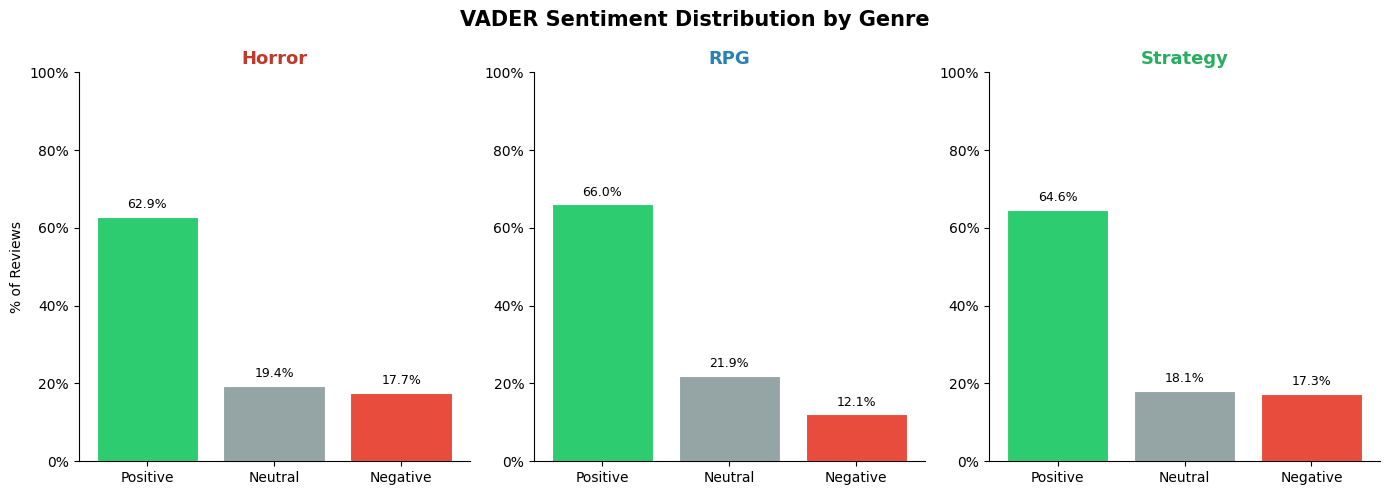

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    sub    = df[df['Genre'] == genre]
    counts = sub['vader_sentiment'].value_counts().reindex(SENT_ORDER, fill_value=0)
    pct    = counts / counts.sum() * 100
    bars   = ax.bar(SENT_ORDER, pct,
                    color=[SENT_COLORS[s] for s in SENT_ORDER],
                    edgecolor='white', linewidth=0.8)
    ax.set_title(genre, fontsize=13, fontweight='bold', color=GENRE_PALETTE[genre])
    ax.set_ylabel('% of Reviews' if ax is axes[0] else '')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    for bar, val in zip(bars, pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('VADER Sentiment Distribution by Genre', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Average compound score per game

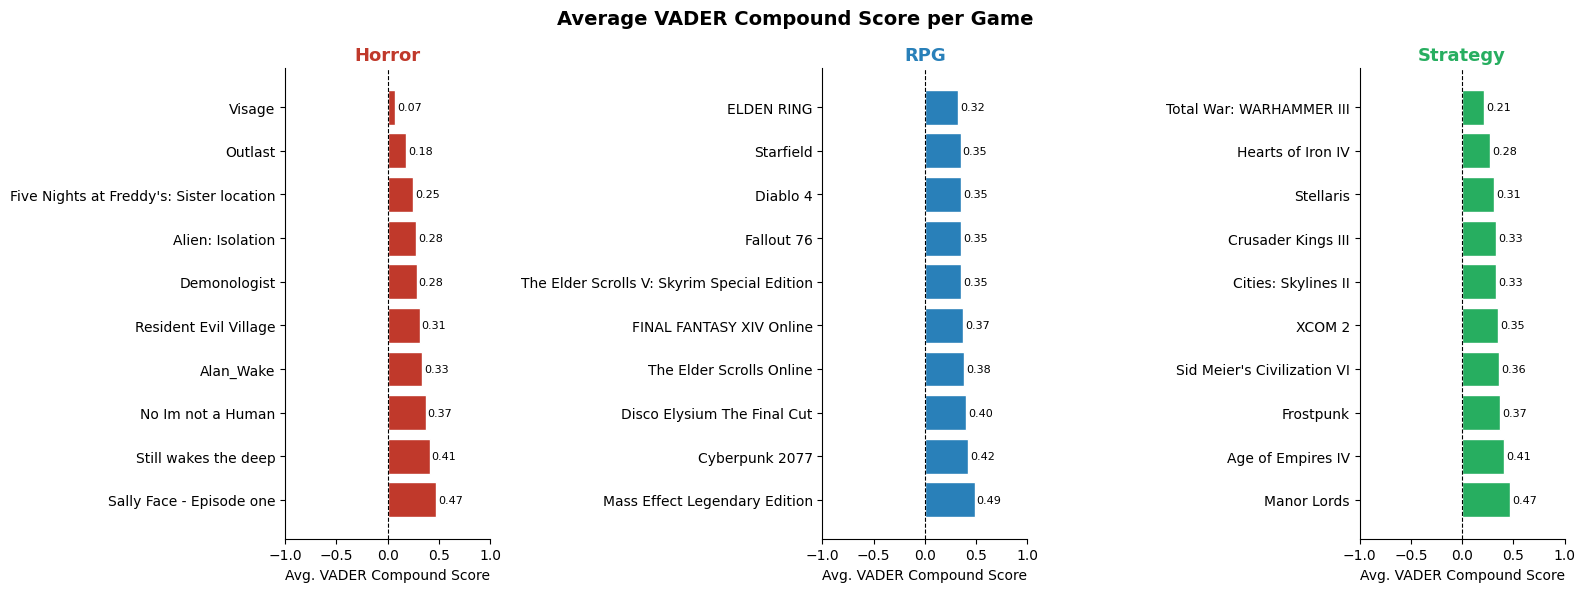

In [9]:
game_sent = (
    df.groupby(['Genre', 'Game_name'])['vader_compound']
    .mean().reset_index()
    .rename(columns={'vader_compound': 'avg_compound'})
    .sort_values(['Genre', 'avg_compound'], ascending=[True, False])
)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    sub    = game_sent[game_sent['Genre'] == genre]
    colors = [GENRE_PALETTE[genre] if v >= 0 else '#e74c3c' for v in sub['avg_compound']]
    bars   = ax.barh(sub['Game_name'], sub['avg_compound'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(genre, fontsize=13, fontweight='bold', color=GENRE_PALETTE[genre])
    ax.set_xlabel('Avg. VADER Compound Score')
    ax.set_xlim(-1, 1)
    for bar, val in zip(bars, sub['avg_compound']):
        offset = 0.02 if val >= 0 else -0.02
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Average VADER Compound Score per Game', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_by_game.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Playtime at review vs sentiment

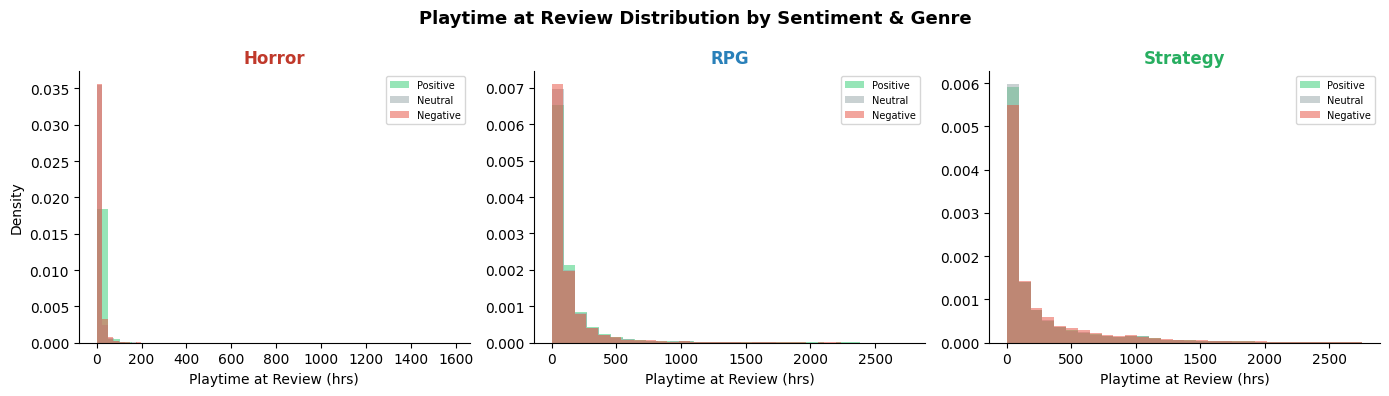

Correlation between playtime_at_review and vader_compound (by genre):
Genre
Horror      0.024
RPG         0.003
Strategy   -0.002
Name: playtime_at_review, dtype: float64


In [10]:
df['playtime_hours'] = df['playtime_at_review'] / 60
cap   = df['playtime_hours'].quantile(0.99)
df_pt = df[df['playtime_hours'] <= cap].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    sub = df_pt[df_pt['Genre'] == genre]
    for lbl, color in SENT_COLORS.items():
        grp = sub[sub['vader_sentiment'] == lbl]['playtime_hours']
        if len(grp) > 0:
            ax.hist(grp, bins=30, alpha=0.5, label=lbl, color=color, density=True)
    ax.set_title(genre, fontsize=12, fontweight='bold', color=GENRE_PALETTE[genre])
    ax.set_xlabel('Playtime at Review (hrs)')
    ax.set_ylabel('Density' if ax is axes[0] else '')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Playtime at Review Distribution by Sentiment & Genre',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('playtime_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation between playtime_at_review and vader_compound (by genre):')
print(df.groupby('Genre')[['playtime_at_review','vader_compound']]
      .corr().unstack()['vader_compound']['playtime_at_review'].round(3))

### 3.5 Upvote-weighted compound score

In [11]:
def weighted_mean(group):
    weights = group['votes_up'] + 1
    return np.average(group['vader_compound'], weights=weights)

weighted_by_genre   = df.groupby('Genre').apply(weighted_mean).rename('weighted_compound')
unweighted_by_genre = df.groupby('Genre')['vader_compound'].mean().rename('unweighted_compound')
comparison = pd.concat([unweighted_by_genre, weighted_by_genre], axis=1).round(4)
print('Unweighted vs vote-weighted compound score by genre:')
print(comparison)

Unweighted vs vote-weighted compound score by genre:
          unweighted_compound  weighted_compound
Genre                                           
Horror                 0.3260             0.2812
RPG                    0.3802             0.3389
Strategy               0.3215             0.1923


### 3.6 Sentiment over time by genre

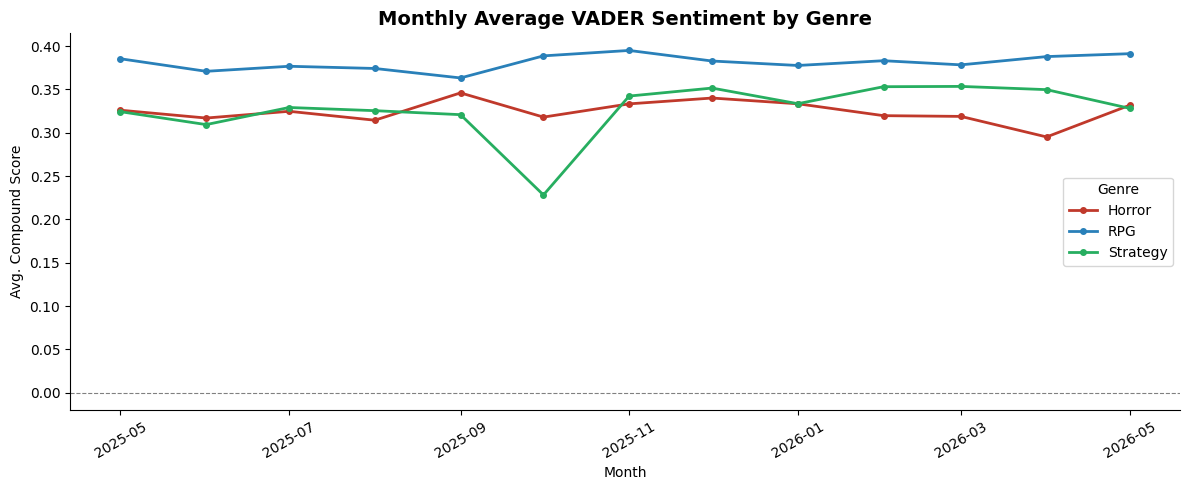

In [12]:
monthly = (
    df.groupby(['month', 'Genre'])['vader_compound']
    .mean().reset_index()
)
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
for genre, grp in monthly.groupby('Genre'):
    grp = grp.sort_values('month_dt')
    ax.plot(grp['month_dt'], grp['vader_compound'],
            label=genre, color=GENRE_PALETTE[genre],
            linewidth=2, marker='o', markersize=4)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Monthly Average VADER Sentiment by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg. Compound Score')
ax.legend(title='Genre')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4 – Topic Modelling (LDA)

In [13]:
def build_corpus(tokens_series):
    dictionary = corpora.Dictionary(tokens_series)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(t) for t in tokens_series]
    return dictionary, corpus

genre_data = {}
for genre in ['Horror', 'RPG', 'Strategy']:
    tokens = df[df['Genre'] == genre]['tokens'].tolist()
    d, c   = build_corpus(tokens)
    genre_data[genre] = {'tokens': tokens, 'dictionary': d, 'corpus': c}
    print(f'  {genre}: {len(c):,} reviews | {len(d):,} unique tokens')

  Horror: 29,529 reviews | 7,181 unique tokens
  RPG: 125,866 reviews | 15,429 unique tokens
  Strategy: 63,198 reviews | 10,475 unique tokens


In [14]:
NUM_TOPICS = 5

print(f'Training LDA models ({NUM_TOPICS} topics per genre)...')
lda_models = {}
for genre in ['Horror', 'RPG', 'Strategy']:
    gd = genre_data[genre]
    m  = LdaModel(corpus=gd['corpus'], id2word=gd['dictionary'],
                  num_topics=NUM_TOPICS, random_state=42,
                  passes=15, alpha='auto', eta='auto')
    lda_models[genre] = m
    cm = CoherenceModel(model=m, texts=gd['tokens'],
                        dictionary=gd['dictionary'], coherence='c_v')
    print(f'  {genre} coherence (c_v): {cm.get_coherence():.4f}')

Training LDA models (5 topics per genre)...
  Horror coherence (c_v): 0.5236
  RPG coherence (c_v): 0.5320
  Strategy coherence (c_v): 0.5898


### 4.1 Top words per topic

In [15]:
for genre in ['Horror', 'RPG', 'Strategy']:
    print(f'\n{genre}')
    for t in range(NUM_TOPICS):
        words = ', '.join([w for w, _ in lda_models[genre].show_topic(t, topn=10)])
        print(f'  Topic {t+1}: {words}')


Horror
  Topic 1: love, absolute, barry, que, pants, cinema, larry, sal, travis, freddy
  Topic 2: story, best, amazing, worth, scary, peak, gameplay, art, style, definitely
  Topic 3: horror, atmosphere, experience, feel, alien, design, story, makes, feels, yes
  Topic 4: people, endings, characters, lot, human, visitor, save, character, different, times
  Topic 5: cool, face, sally, guy, man, evil, fema, resident, house, cat

RPG
  Topic 1: let, man, hate, class, funny, kill, murder, dragon, account, yeah
  Topic 2: best, love, amazing, story, life, worth, buy, peak, favorite, masterpiece
  Topic 3: mods, years, bethesda, diablo, mod, bought, company, modding, work, buy
  Topic 4: world, story, disco, characters, experience, rpg, elysium, writing, art, feels
  Topic 5: skyrim, new, people, lot, better, content, things, story, character, quests

Strategy
  Topic 1: better, love, mods, lot, best, hard, strategy, things, need, pretty
  Topic 2: builder, germany, fps, information, naval

### 4.2 Word clouds

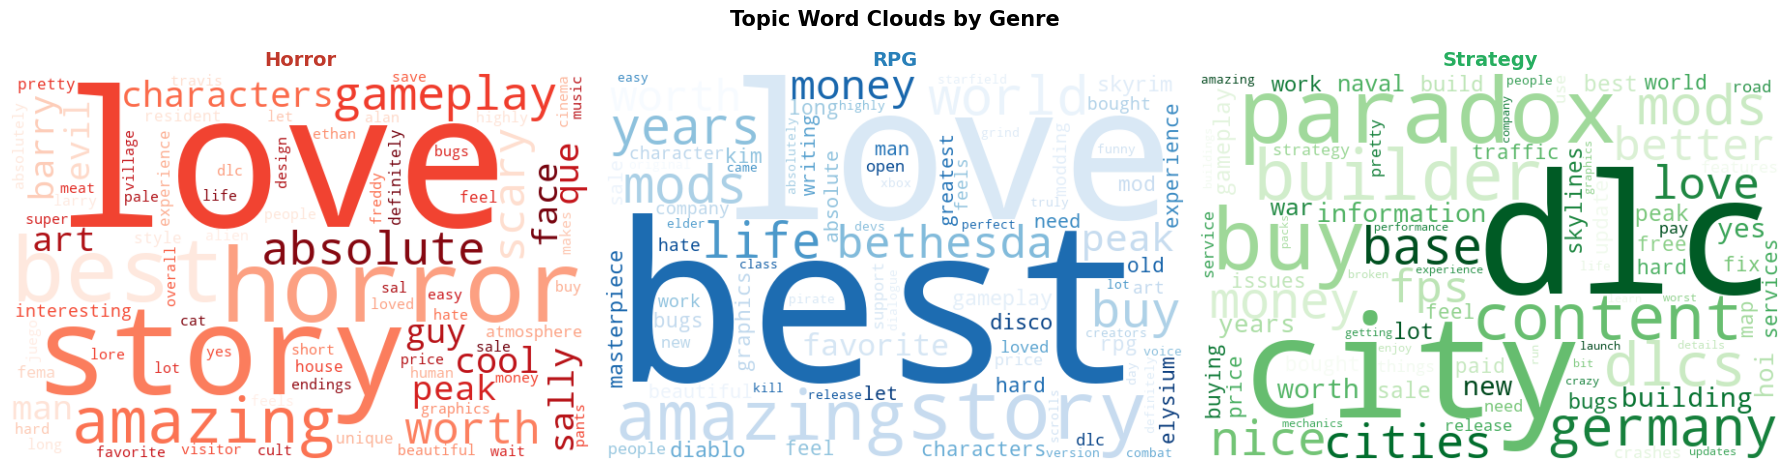

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    word_weights = {}
    for t in range(NUM_TOPICS):
        for word, weight in lda_models[genre].show_topic(t, topn=40):
            word_weights[word] = word_weights.get(word, 0) + weight
    cmap = 'Reds' if genre == 'Horror' else ('Blues' if genre == 'RPG' else 'Greens')
    wc   = WordCloud(width=600, height=400, background_color='white',
                     colormap=cmap, max_words=80)\
           .generate_from_frequencies(word_weights)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(genre, fontsize=14, fontweight='bold', color=GENRE_PALETTE[genre])

fig.suptitle('Topic Word Clouds by Genre', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('topic_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Topic word heatmap

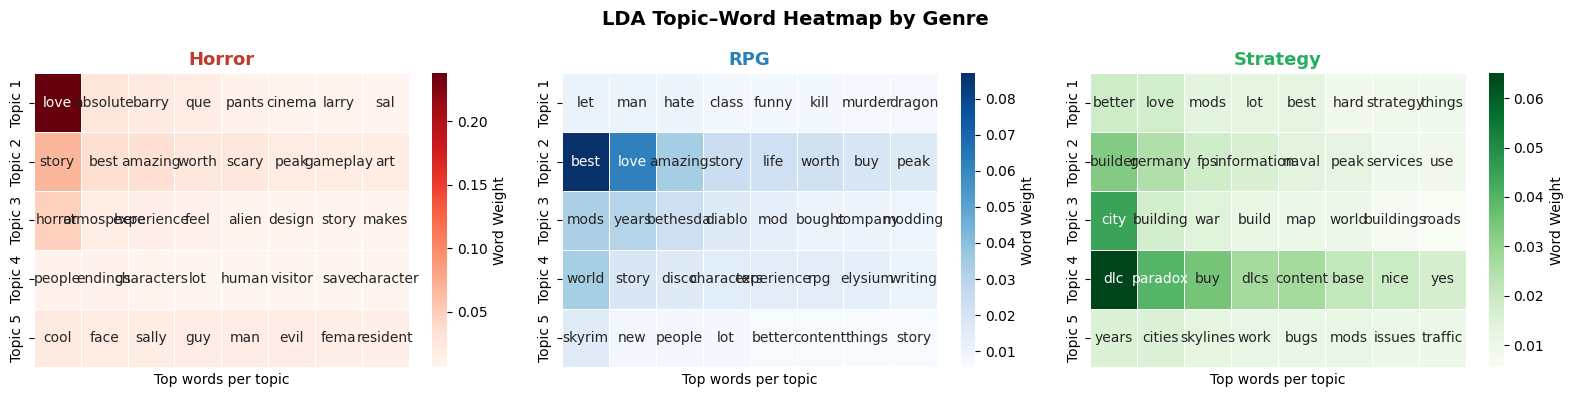

In [17]:
N_SHOW = 8
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    matrix, annot = [], []
    for t in range(NUM_TOPICS):
        pairs = lda_models[genre].show_topic(t, topn=N_SHOW)
        matrix.append([s for _, s in pairs])
        annot.append([w for w, _ in pairs])
    cmap = 'Reds' if genre == 'Horror' else ('Blues' if genre == 'RPG' else 'Greens')
    sns.heatmap(np.array(matrix), ax=ax, cmap=cmap,
                annot=annot, fmt='',
                yticklabels=[f'Topic {i+1}' for i in range(NUM_TOPICS)],
                xticklabels=False, linewidths=0.5,
                cbar_kws={'label': 'Word Weight'})
    ax.set_title(genre, fontsize=13, fontweight='bold', color=GENRE_PALETTE[genre])
    ax.set_xlabel('Top words per topic')

fig.suptitle('LDA Topic–Word Heatmap by Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Average sentiment per dominant topic

Assigning dominant topic to each review...


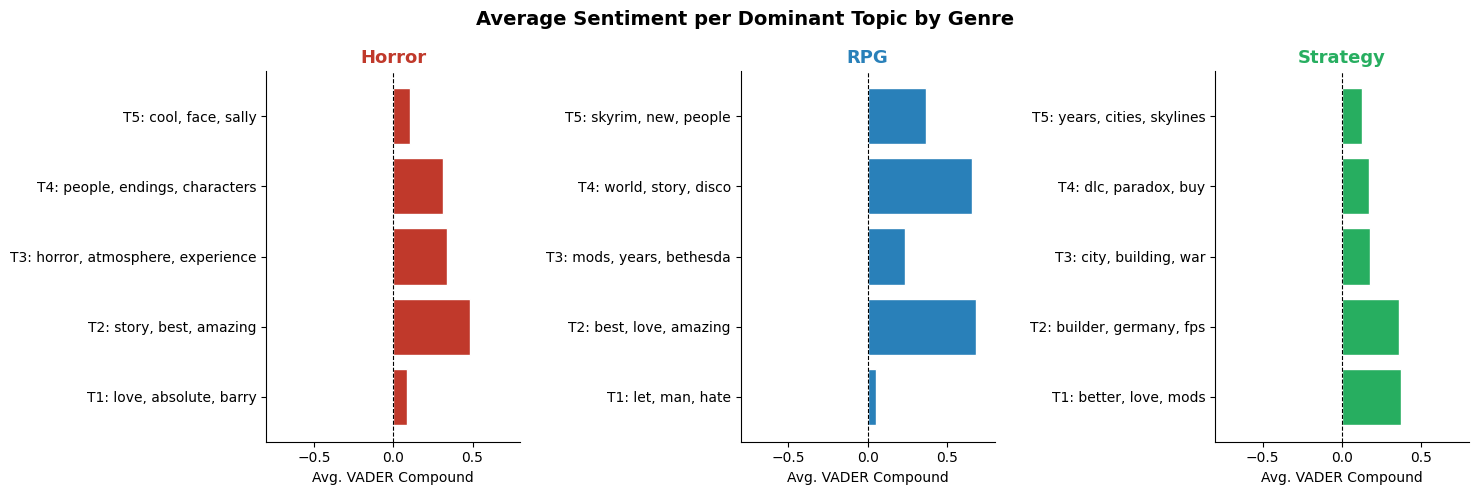

In [18]:
print('Assigning dominant topic to each review...')
dominant = []
for _, row in df.iterrows():
    gd  = genre_data[row['Genre']]
    bow = gd['dictionary'].doc2bow(row['tokens'])
    topics = lda_models[row['Genre']].get_document_topics(bow)
    dominant.append(max(topics, key=lambda x: x[1])[0] if topics else -1)
df['dominant_topic'] = dominant

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    sub = df[(df['Genre'] == genre) & (df['dominant_topic'] >= 0)].copy()
    ts  = (sub.groupby('dominant_topic')['vader_compound']
              .agg(['mean','count']).reset_index()
              .rename(columns={'mean':'avg','count':'n'}))
    model  = lda_models[genre]
    labels = {t: f'T{t+1}: ' + ', '.join([w for w,_ in model.show_topic(t, topn=3)])
              for t in range(NUM_TOPICS)}
    ts['label']  = ts['dominant_topic'].map(labels)
    colors = [GENRE_PALETTE[genre] if v >= 0 else '#e74c3c' for v in ts['avg']]
    ax.barh(ts['label'], ts['avg'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(genre, fontsize=13, fontweight='bold', color=GENRE_PALETTE[genre])
    ax.set_xlabel('Avg. VADER Compound')
    ax.set_xlim(-0.8, 0.8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Average Sentiment per Dominant Topic by Genre',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 – Network Analysis

### 5.1 Build the bipartite user–game graph

In [19]:
B = nx.Graph()

# User nodes
users = df['steamid'].dropna().unique()
B.add_nodes_from(users, bipartite='user')

# Game nodes — prefix 'g_' to avoid steamid collision
game_node = {aid: f'g_{aid}' for aid in df['appid'].unique()}
for aid, gn in game_node.items():
    row = appid_dict.get(aid, [aid, 'Unknown'])
    B.add_node(gn, bipartite='game', appid=aid, Game_name=row[0], Genre=row[1])

# Edges: user reviewed game
edge_counts = (
    df.dropna(subset=['steamid'])
      .groupby(['steamid', 'appid'])
      .size().reset_index(name='n_reviews')
)
for _, row in edge_counts.iterrows():
    B.add_edge(row['steamid'], game_node[row['appid']], weight=int(row['n_reviews']))

user_nodes = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 'user'}
game_nodes = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 'game'}

print(f'Bipartite graph')
print(f'  User nodes : {len(user_nodes):,}')
print(f'  Game nodes : {len(game_nodes):,}')
print(f'  Edges      : {B.number_of_edges():,}')
print(f'  Is bipartite: {bipartite.is_bipartite(B)}')

Bipartite graph
  User nodes : 207,832
  Game nodes : 30
  Edges      : 218,593
  Is bipartite: True


### 5.2 Cross-genre reviewer behaviour

Cross-genre reviewer distribution:
  1 genre: 203,528 users (97.9%)
  2 genres: 4,196 users (2.0%)
  3 genres: 108 users (0.1%)


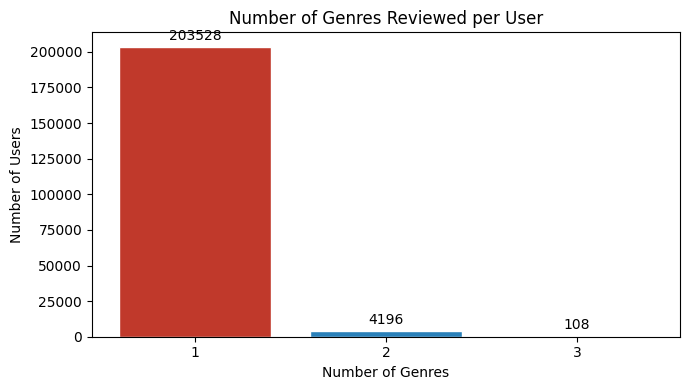

In [20]:
user_genre_map = (
    df.dropna(subset=['steamid'])
      .groupby('steamid')['Genre']
      .apply(set)
)

user_genres = user_genre_map.apply(len).reset_index()
user_genres.columns = ['steamid', 'n_genres']
dist  = user_genres['n_genres'].value_counts().sort_index()
total = len(user_genres)

print('Cross-genre reviewer distribution:')
for n, cnt in dist.items():
    g = 'genre' if n == 1 else 'genres'
    print(f'  {n} {g}: {cnt:,} users ({cnt/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    dist.index.astype(str), dist.values,
    color=[list(GENRE_PALETTE.values())[i] for i in range(len(dist))],
    edgecolor='white'
)
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Number of Genres Reviewed per User')
ax.set_xlabel('Number of Genres')
ax.set_ylabel('Number of Users')
plt.tight_layout()
plt.savefig('fig_cross_genre_users.png', bbox_inches='tight')
plt.show()

### 5.3 Genre co-occurrence graph

Two genres are connected when at least one user reviewed both. Edge weight = number of shared reviewers.

Genre co-occurrence edges:
  Horror ↔ RPG:  1,833 shared reviewers
  Horror ↔ Strategy:  425 shared reviewers
  RPG ↔ Strategy:  2,262 shared reviewers


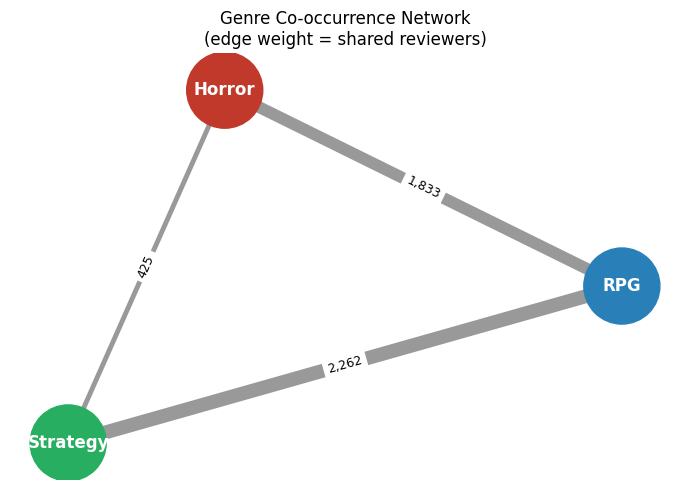

In [21]:
genres = ['Horror', 'RPG', 'Strategy']

genre_graph = nx.Graph()
genre_graph.add_nodes_from(genres)

for uid, genre_set in user_genre_map.items():
    for g1, g2 in combinations(sorted(genre_set), 2):
        if genre_graph.has_edge(g1, g2):
            genre_graph[g1][g2]['weight'] += 1
        else:
            genre_graph.add_edge(g1, g2, weight=1)

print('Genre co-occurrence edges:')
for u, v, d in genre_graph.edges(data=True):
    print(f'  {u} ↔ {v}:  {d["weight"]:,} shared reviewers')

fig, ax = plt.subplots(figsize=(7, 5))
pos     = nx.spring_layout(genre_graph, seed=42, k=2)
weights = [genre_graph[u][v]['weight'] for u, v in genre_graph.edges()]
max_w   = max(weights) if weights else 1
widths  = [2 + 8 * (w / max_w) for w in weights]

nx.draw_networkx_nodes(
    genre_graph, pos, node_size=3000,
    node_color=[GENRE_PALETTE[g] for g in genres], ax=ax
)
nx.draw_networkx_labels(genre_graph, pos, font_size=12,
                        font_weight='bold', font_color='white', ax=ax)
nx.draw_networkx_edges(genre_graph, pos, width=widths,
                       edge_color='#555555', alpha=0.6, ax=ax)
nx.draw_networkx_edge_labels(
    genre_graph, pos,
    edge_labels={(u, v): f"{d['weight']:,}" for u, v, d in genre_graph.edges(data=True)},
    font_size=9, ax=ax
)
ax.set_title('Genre Co-occurrence Network\n(edge weight = shared reviewers)')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_genre_cooccurrence.png', bbox_inches='tight')
plt.show()

### 5.4 SNA measures

In [22]:
if genre_graph.number_of_edges() > 0:
    sna = pd.DataFrame({
        'Degree Centrality'      : nx.degree_centrality(genre_graph),
        'Betweenness Centrality' : nx.betweenness_centrality(genre_graph, weight='weight'),
        'Closeness Centrality'   : nx.closeness_centrality(genre_graph),
    }).round(4)
    print(sna.to_string())
    print(f'\nTransitivity : {nx.transitivity(genre_graph):.4f}')
    print(f'Density      : {nx.density(genre_graph):.4f}')
else:
    print('No cross-genre reviewers found.')

          Degree Centrality  Betweenness Centrality  Closeness Centrality
Horror                  1.0                     1.0                   1.0
RPG                     1.0                     0.0                   1.0
Strategy                1.0                     0.0                   1.0

Transitivity : 1.0000
Density      : 1.0000


### 5.5 Bipartite graph visualisation (top reviewers)

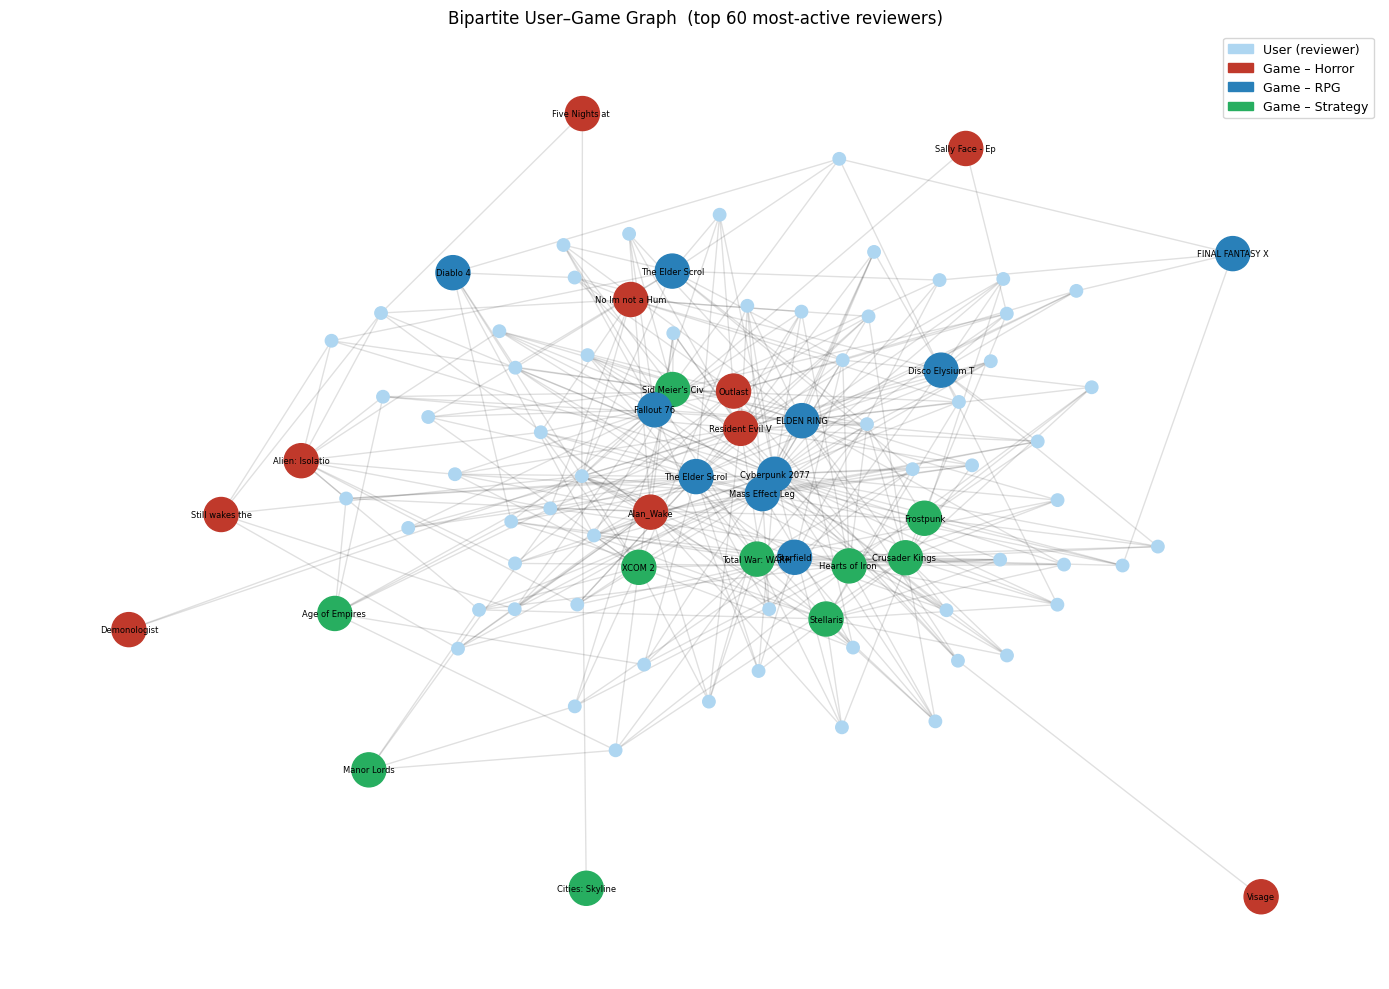

In [23]:
TOP_N = 60

top_users = (
    df.dropna(subset=['steamid'])
      .groupby('steamid')['appid']
      .nunique().nlargest(TOP_N).index.tolist()
)

sub_nodes = set(top_users)
for u in top_users:
    if u in B:
        sub_nodes.update(B.neighbors(u))
sub_B = B.subgraph(sub_nodes).copy()

node_colors, node_sizes = [], []
for n, d in sub_B.nodes(data=True):
    if d.get('bipartite') == 'user':
        node_colors.append('#AED6F1')
        node_sizes.append(80)
    else:
        node_colors.append(GENRE_PALETTE.get(d.get('Genre', ''), '#AAAAAA'))
        node_sizes.append(600)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(sub_B, seed=42, k=0.5)
nx.draw_networkx_nodes(sub_B, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
nx.draw_networkx_edges(sub_B, pos, alpha=0.12, ax=ax)
game_labels = {
    n: d.get('Game_name', n)[:15]
    for n, d in sub_B.nodes(data=True)
    if d.get('bipartite') == 'game'
}
nx.draw_networkx_labels(sub_B, pos, labels=game_labels, font_size=6, ax=ax)

legend_handles = [mpatches.Patch(color='#AED6F1', label='User (reviewer)')]
for g, c in GENRE_PALETTE.items():
    legend_handles.append(mpatches.Patch(color=c, label=f'Game – {g}'))
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
ax.set_title(f'Bipartite User–Game Graph  (top {TOP_N} most-active reviewers)')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_bipartite_graph.png', bbox_inches='tight')
plt.show()

### 5.6 User degree distribution

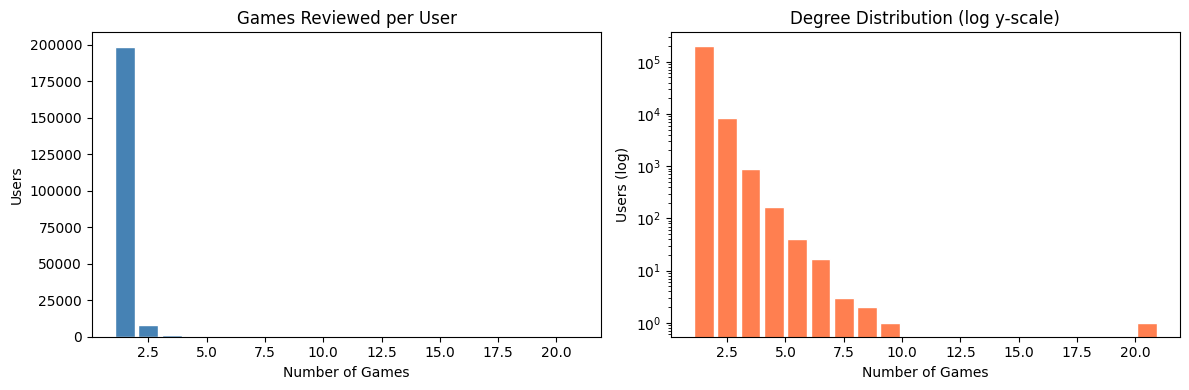

count    207832.000000
mean          1.051777
std           0.262784
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: games_reviewed, dtype: float64


In [26]:
user_degree = pd.Series(
    {n: B.degree(n) for n in user_nodes},
    name='games_reviewed'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
max_bin = min(int(user_degree.max()) + 2, 25)

axes[0].hist(user_degree, bins=range(1, max_bin),
             color='steelblue', edgecolor='white', rwidth=0.85)
axes[0].set_title('Games Reviewed per User')
axes[0].set_xlabel('Number of Games')
axes[0].set_ylabel('Users')

axes[1].hist(user_degree, bins=range(1, max_bin),
             color='coral', edgecolor='white', rwidth=0.85, log=True)
axes[1].set_title('Degree Distribution (log y-scale)')
axes[1].set_xlabel('Number of Games')
axes[1].set_ylabel('Users (log)')

plt.tight_layout()
plt.savefig('fig_degree_distribution.png', bbox_inches='tight')
plt.show()
print(user_degree.describe())

---
## 6 – Community Detection

Project bipartite graph onto games (games share an edge if they share reviewers), then detect communities.

In [27]:
game_proj  = bipartite.weighted_projected_graph(B, game_nodes)
print(f'Game projection: {game_proj.number_of_nodes()} nodes, {game_proj.number_of_edges()} edges')

communities    = list(greedy_modularity_communities(game_proj, weight='weight'))
node_community = {n: i for i, comm in enumerate(communities) for n in comm}

print(f'Communities detected: {len(communities)}')
for i, comm in enumerate(communities):
    genre_breakdown = Counter(B.nodes[n].get('Genre', '?') for n in comm)
    names = [B.nodes[n].get('Game_name', n) for n in comm]
    print(f'  Community {i}: {dict(genre_breakdown)} → {names}')

Game projection: 30 nodes, 413 edges
Communities detected: 3
  Community 0: {'RPG': 5, 'Horror': 10} → ['Cyberpunk 2077', 'The Elder Scrolls V: Skyrim Special Edition', 'Disco Elysium The Final Cut', 'Resident Evil Village', 'Outlast', 'Visage', 'Sally Face - Episode one', 'Mass Effect Legendary Edition', 'ELDEN RING', 'No Im not a Human', "Five Nights at Freddy's: Sister location", 'Demonologist', 'Alien: Isolation', 'Alan_Wake', 'Still wakes the deep']
  Community 1: {'Strategy': 10} → ['Hearts of Iron IV', 'Cities: Skylines II', 'Stellaris', 'Crusader Kings III', 'Total War: WARHAMMER III', 'Frostpunk', 'Manor Lords', "Sid Meier's Civilization VI", 'Age of Empires IV', 'XCOM 2']
  Community 2: {'RPG': 5} → ['Starfield', 'FINAL FANTASY XIV Online', 'Fallout 76', 'The Elder Scrolls Online', 'Diablo 4']


C:\Users\adity\AppData\Local\Temp\ipykernel_36764\4017647088.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', max(len(communities), 2))


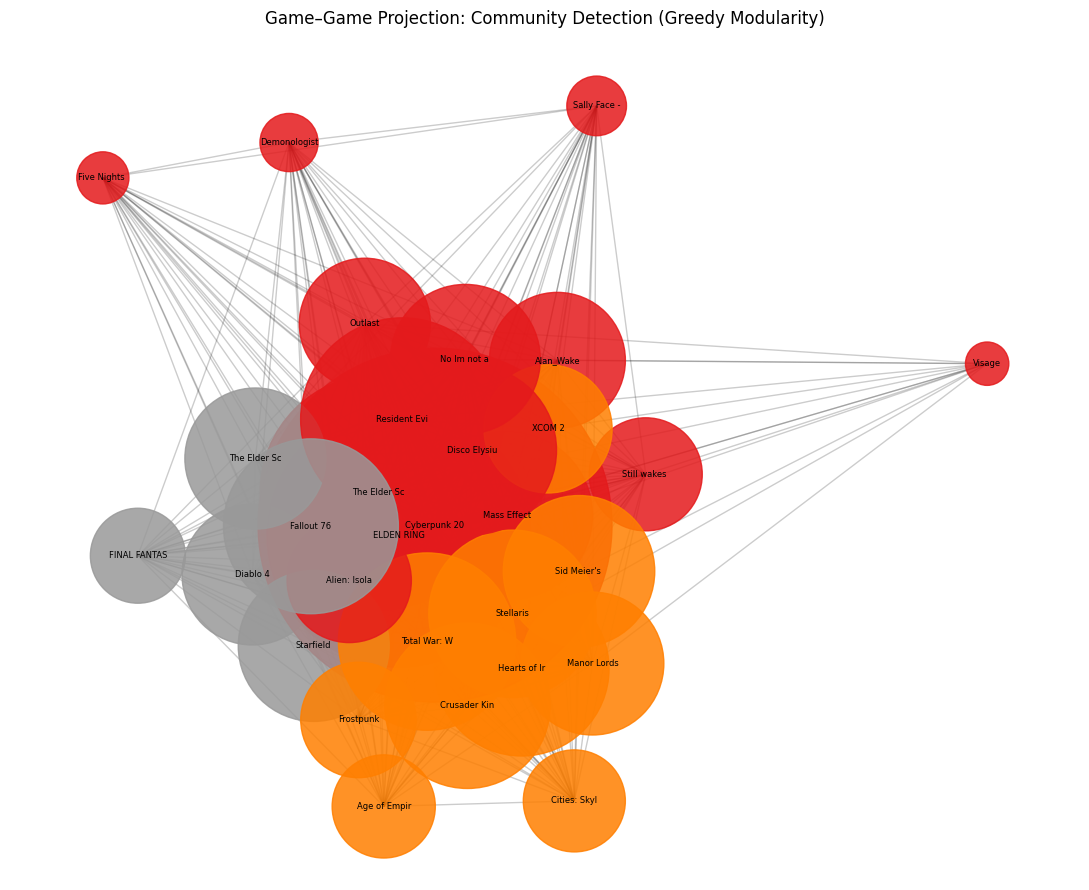

In [28]:
fig, ax = plt.subplots(figsize=(11, 9))
pos  = nx.spring_layout(game_proj, seed=42, k=1.8)
cmap = plt.cm.get_cmap('Set1', max(len(communities), 2))

nc = [cmap(node_community.get(n, 0)) for n in game_proj.nodes()]
ns = [300 + 15 * game_proj.degree(n, weight='weight') for n in game_proj.nodes()]

nx.draw_networkx_nodes(game_proj, pos, node_color=nc, node_size=ns, ax=ax, alpha=0.85)
nx.draw_networkx_edges(game_proj, pos, alpha=0.2, ax=ax)
nx.draw_networkx_labels(
    game_proj, pos,
    labels={n: B.nodes[n].get('Game_name', n)[:12] for n in game_proj.nodes()},
    font_size=6, ax=ax
)
ax.set_title('Game–Game Projection: Community Detection (Greedy Modularity)')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_community_detection.png', bbox_inches='tight')
plt.show()

---
## 7 – Summary & Export

In [29]:
summary = df.groupby('Genre').agg(
    n_reviews       = ('review',         'count'),
    n_unique_users  = ('steamid',        'nunique'),
    mean_compound   = ('vader_compound', 'mean'),
    median_compound = ('vader_compound', 'median'),
    pct_positive    = ('vader_sentiment', lambda x: (x == 'Positive').mean() * 100),
    pct_neutral     = ('vader_sentiment', lambda x: (x == 'Neutral').mean()  * 100),
    pct_negative    = ('vader_sentiment', lambda x: (x == 'Negative').mean() * 100),
).reindex(['Horror', 'RPG', 'Strategy']).round(3)

print(summary.to_string())

df.to_csv('steam_reviews_with_sentiment.csv', index=False)
summary.to_csv('sentiment_summary_by_genre.csv')
nx.write_graphml(B,           'bipartite_user_game.graphml')
nx.write_graphml(genre_graph, 'genre_cooccurrence.graphml')
nx.write_graphml(game_proj,   'game_projection.graphml')
print('\nAll files saved.')

          n_reviews  n_unique_users  mean_compound  median_compound  pct_positive  pct_neutral  pct_negative
Genre                                                                                                       
Horror        29529           28775          0.326            0.440        62.894       19.445        17.661
RPG          125866          121893          0.380            0.459        66.048       21.885        12.067
Strategy      63198           61576          0.321            0.440        64.591       18.088        17.322

All files saved.
